In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('C:\\Users\\Sarah\\Downloads\\Seattle.csv')

In [3]:
df

,id,host_id,host_name,host_since,host_response_rate,host_listings_count,host_total_listings_count,city,state,zipcode,...,security_deposit,cleaning_fee,guests_included,extra_people,minimum_nights,maximum_nights,number_of_reviews,review_scores_rating,cancellation_policy,reviews_per_month
0,241032,956883,Maija,11-08-2011,96%,3.0,3.0,Seattle,WA,98119,...,NaN,NaN,2,5,1,365,207,95.0,moderate,4.07
1,953595,5177328,Andrea,21-02-2013,98%,6.0,6.0,Seattle,WA,98119,...,100,40.0,1,0,2,90,43,96.0,strict,1.48
2,3308979,16708587,Jill,12-06-2014,67%,2.0,2.0,Seattle,WA,98119,...,"1,000.00",300.0,10,25,4,30,20,97.0,strict,1.15
3,7421966,9851441,Emily,06-11-2013,NaN,1.0,1.0,Seattle,WA,98119,...,NaN,NaN,1,0,1,1125,0,NaN,flexible,NaN
4,278830,1452570,Emily,29-11-2011,100%,2.0,2.0,Seattle,WA,98119,...,700,125.0,6,15,1,1125,38,92.0,strict,0.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3813,8101950,31148752,Bo,13-04-2015,99%,354.0,354.0,Seattle,WA,98107,...,NaN,230.0,1,0,3,1125,1,80.0,strict,0.30
3814,8902327,46566046,Glen,14-10-2015,100%,1.0,1.0,Seattle,WA,98102,...,500,50.0,3,25,2,29,2,100.0,moderate,2.00
3815,10267360,52791370,Virginia,30-12-2015,NaN,1.0,1.0,Seattle,WA,98178,...,250,35.0,2,20,1,7,0,NaN,moderate,NaN
3816,9604740,25522052,Karen,03-01-2015,100%,1.0,1.0,Seattle,WA,98112,...,300,45.0,1,0,3,1125,0,NaN,moderate,NaN


In [4]:
# Creating a back up copy of the original data

df_copy = df.copy()

In [5]:
# Dataset column details
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         3818 non-null   int64  
 1   host_id                    3818 non-null   int64  
 2   host_name                  3816 non-null   object 
 3   host_since                 3816 non-null   object 
 4   host_response_rate         3295 non-null   object 
 5   host_listings_count        3816 non-null   float64
 6   host_total_listings_count  3816 non-null   float64
 7   city                       3818 non-null   object 
 8   state                      3818 non-null   object 
 9   zipcode                    3811 non-null   object 
 10  country                    3818 non-null   object 
 11  property_type              3817 non-null   object 
 12  room_type                  3818 non-null   object 
 13  accommodates               3818 non-null   int64

In [6]:
# Rename the titles of the columns

rename_map = {
    "id": "ID",
    "host_id": "Host ID",
    "host_name": "Host Name",
    "host_since": "Host Since",
    "host_response_rate": "Host Response Rate",
    "host_listings_count": "Host Listings Count",
    "host_total_listings_count": "Host Total Listings Count",
    "city": "City",
    "state": "State",
    "zipcode": "Zipcode",
    "country": "Country",
    "property_type": "Property Type",
    "room_type": "Room Type",
    "accommodates": "Accommodates",
    "bathrooms": "Bathrooms",
    "bedrooms": "Bedrooms",
    "beds": "Beds",
    "bed_type": "Bed Type",
    "amenities": "Amenities",
    "price": "Price",
    "weekly_price": "Weekly Price",
    "monthly_price": "Monthly Price",
    "security_deposit": "Security Deposit",
    "cleaning_fee": "Cleaning Fee",
    "guests_included": "Guests Included",
    "extra_people": "Extra People",
    "minimum_nights": "Minimum Nights",
    "maximum_nights": "Maximum Nights",
    "number_of_reviews": "Number of Reviews",
    "review_scores_rating": "Review Scores Rating",
    "cancellation_policy": "Cancellation Policy",
    "reviews_per_month": "Reviews per Month",
}

df = df.rename(columns=rename_map)

In [7]:
# Checking for null values in each column
print(df.isnull().sum())

ID                              0
Host ID                         0
Host Name                       2
Host Since                      2
Host Response Rate            523
Host Listings Count             2
Host Total Listings Count       2
City                            0
State                           0
Zipcode                         7
Country                         0
Property Type                   1
Room Type                       0
Accommodates                    0
Bathrooms                      16
Bedrooms                        6
Beds                            1
Bed Type                        0
Amenities                       0
Price                           0
Weekly Price                 1809
Monthly Price                2301
Security Deposit             1952
Cleaning Fee                 1030
Guests Included                 0
Extra People                    0
Minimum Nights                  0
Maximum Nights                  0
Number of Reviews               0
Review Scores 

In [8]:
# Zipcode and City

zipcode_dict = {'99\n98122': '98122'}

df["Zipcode"] = df["Zipcode"].replace(zipcode_dict)

df['Zipcode'] = df['Zipcode'].astype(str).str.strip()

# Keep only zipcodes that are exactly 5 digits
valid_zip = df['Zipcode'].str.len() == 5
numeric_zip = df['Zipcode'].str.isdigit()

valid_french_zip = valid_zip & numeric_zip

# Set invalid zipcodes to NaN
df.loc[valid_french_zip == False, 'Zipcode'] = np.nan

# City
city_map = {"Seattle": "Seattle", "seattle": "Seattle", "Seattle ": "Seattle",
    "Ballard, Seattle": "Seattle", "West Seattle": "Seattle", "Phinney Ridge Seattle": "Seattle", "西雅图": "Seattle",}

df["City"] = df["City"].replace(city_map)

In [9]:
# Amenities
def clean_amenities(df):

    df['Amenities Count'] = (
        df['Amenities']
        .str.lower()
        .apply(lambda x: 0 if x == 'no amenities listed' else len(x.split(',')))
    )

    return df

df = clean_amenities(df)

In [10]:
# Columns and Rows to be dropped

# Host related columns

host_cols = [
    "Host Name",
    "Host Since",
    "Host Response Rate",
    "Host Listings Count",
    "Host Total Listings Count"
]

# Drop rows where all host related information is missing
df = df.dropna(subset=host_cols, how="all")

# Drop empty City rows
df = df.dropna(subset=['City'])

# Drop Host Total Listings count as it is identical to another column
if df['Host Listings Count'].equals(df['Host Total Listings Count']):
    df = df.drop(columns=['Host Total Listings Count'])

# Host Since
df["Host Since"] = pd.to_datetime(df["Host Since"], format="%d-%m-%Y", errors="coerce")

# Drop the Weekly Price and Monthly Price
df = df.drop(columns=['Weekly Price', 'Monthly Price'])

In [11]:
# Check datatypes of columns

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 3816 entries, 0 to 3817
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ID                    3816 non-null   int64         
 1   Host ID               3816 non-null   int64         
 2   Host Name             3816 non-null   object        
 3   Host Since            3816 non-null   datetime64[ns]
 4   Host Response Rate    3295 non-null   object        
 5   Host Listings Count   3816 non-null   float64       
 6   City                  3816 non-null   object        
 7   State                 3816 non-null   object        
 8   Zipcode               3809 non-null   object        
 9   Country               3816 non-null   object        
 10  Property Type         3815 non-null   object        
 11  Room Type             3816 non-null   object        
 12  Accommodates          3816 non-null   int64         
 13  Bathrooms             3

In [12]:
# Remove commas from currency columns
currency_cols = ['Price', 'Cleaning Fee', 'Security Deposit']

for col in currency_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(',', '', regex=False)
            .str.replace('$', '', regex=False)
            .replace(['nan', 'None', ''], np.nan)
        )
        df[col] = pd.to_numeric(df[col])

if 'Host Response Rate' in df.columns:
    df['Host Response Rate'] = (
        df['Host Response Rate']
        .astype(str)
        .str.replace('%', '', regex=False)
        .replace(['nan', 'None', ''], np.nan)
    )
    df['Host Response Rate'] = pd.to_numeric(df['Host Response Rate'])

In [13]:
# Change datatypes

int_cols = [
    'Host Response Rate',
    'Host Listings Count',
    'Bedrooms',
    'Beds',
    'Price',
    'Security Deposit',
    'Cleaning Fee',
    'Guests Included',
    'Extra People',
    'Minimum Nights',
    'Maximum Nights',
    'Number of Reviews',
    'Amenities Count'
]

for col in int_cols:
    df[col] = df[col].astype('Int64')

In [14]:
# Fill numerical columns
# Impute with median
median_cols = [
    'Host Response Rate',
    'Bathrooms',
    'Bedrooms',
    'Beds',
    'Review Scores Rating',
    'Price'
]

for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

# Impute with 0
zero_cols = [
    'Security Deposit',
    'Cleaning Fee',
    'Reviews per Month'
]

for col in zero_cols:
    df[col] = df[col].fillna(0)

# Impute with mode

prop_mode = df["Property Type"].mode()[0]
df["Property Type"] = df["Property Type"].fillna(prop_mode)

zip_mode = df["Zipcode"].mode().iloc[0]
df["Zipcode"] = df["Zipcode"].fillna(zip_mode)

In [15]:
# After filling missing values

print(df.isnull().sum())

ID                      0
Host ID                 0
Host Name               0
Host Since              0
Host Response Rate      0
Host Listings Count     0
City                    0
State                   0
Zipcode                 0
Country                 0
Property Type           0
Room Type               0
Accommodates            0
Bathrooms               0
Bedrooms                0
Beds                    0
Bed Type                0
Amenities               0
Price                   0
Security Deposit        0
Cleaning Fee            0
Guests Included         0
Extra People            0
Minimum Nights          0
Maximum Nights          0
Number of Reviews       0
Review Scores Rating    0
Cancellation Policy     0
Reviews per Month       0
Amenities Count         0
dtype: int64


In [16]:
# Outliers treatment

outlier_cols = [
    'Maximum Nights', 'Minimum Nights', 'Cleaning Fee',
    'Extra People', 'Security Deposit',
    'Number of Reviews', 'Reviews per Month']

def clip_outliers(df, col):
    df[col] = df[col].astype(float)
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower, upper)
    return df

for col in outlier_cols:
    if col in df.columns:
        df = clip_outliers(df, col)

In [17]:
# Change the datatypes back to int

for col in int_cols:
    df[col] = df[col].round().astype("Int64")

In [18]:
# Take a copy of the cleaned dataframe

df_cleaned = df.copy()

In [19]:
# Save the cleaned dataframe

df.to_csv('Cleaned_France_data.csv', index=False)

In [20]:
pip install sqlalchemy pymysql pandas

Note: you may need to restart the kernel to use updated packages.


In [21]:
df_sql = df_cleaned.copy()

df_sql = df_sql.drop(['Amenities'], axis=1)

from sqlalchemy import create_engine

# MySQL connection
engine = create_engine(f"mysql+pymysql://{uname}:{pwd}@{hostname}:{port}/{dbname}")

# Import DataFrame into SQL
df_sql.to_sql('seattle_data', con=engine, if_exists='replace', index=False)

3816

# Exploratory Data Analysis

## 1. Listing and Host Performance Analysis:

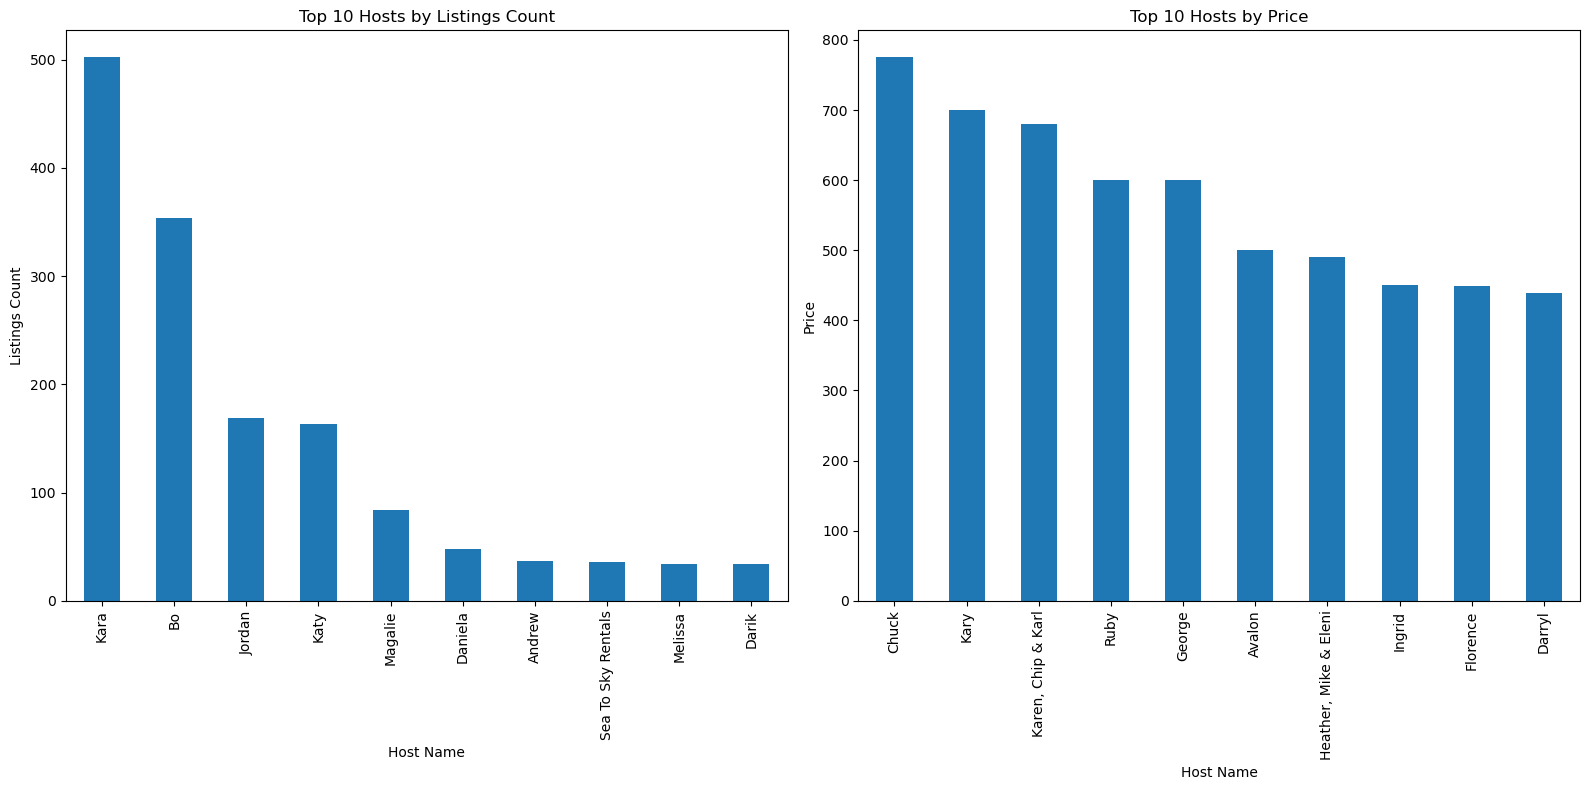

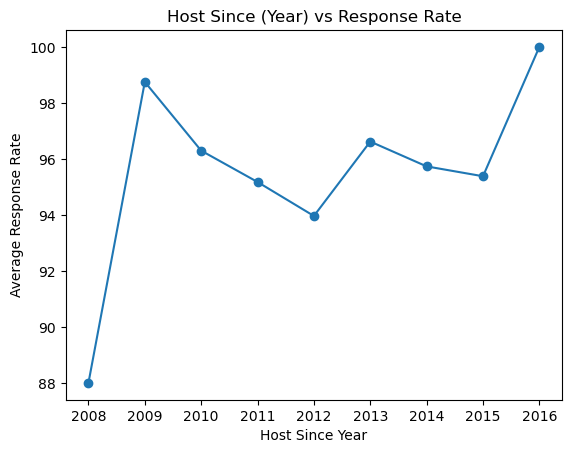

In [22]:
plt.figure(figsize=(16, 8))

# Top 10 Hosts by Listings Count
plt.subplot(1, 2, 1)
df.groupby('Host Name')['Host Listings Count'].max().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Hosts by Listings Count")
plt.xlabel("Host Name")
plt.ylabel("Listings Count")

# Top 10 Hosts by Price
plt.subplot(1, 2, 2)
df.groupby('Host Name')['Price'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Hosts by Price")
plt.xlabel("Host Name")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# Response Rate by Year of Joining
df['Host Year'] = df['Host Since'].dt.year

df.groupby('Host Year')['Host Response Rate'].mean().plot(kind='line', marker='o')
plt.title("Host Since (Year) vs Response Rate")
plt.xlabel("Host Since Year")
plt.ylabel("Average Response Rate")
plt.show()

**Interpretation:**

1. A few hosts manage a significantly higher number of listings compared to others, indicating the presence of professional hosts, while the majority operate with smaller portfolios.

2. High-priced listings are distributed across different hosts and are not limited to those with the largest portfolios, suggesting that pricing depends more on property features than host size.

3. Response rates are consistently high across all host experience levels, with minor fluctuations, indicating that responsiveness is a standard expectation regardless of host tenure.

## 2. Customer Experience & Satisfaction

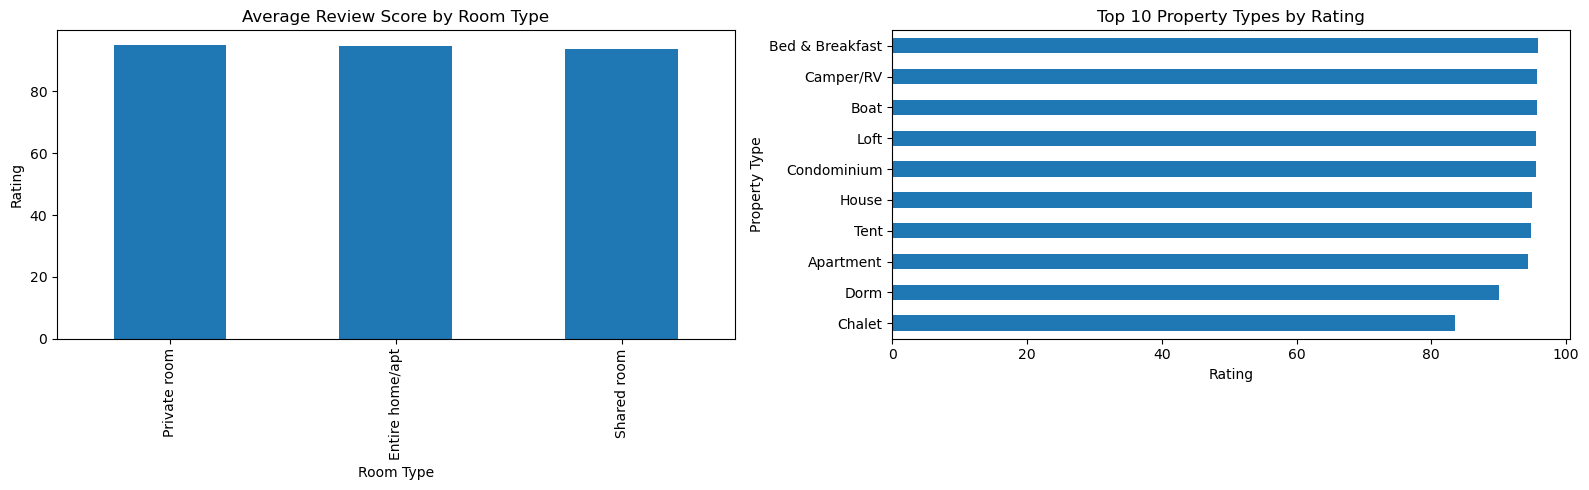

The correlation coefficient of Reviews per Month and Number of Reviews: 0.69


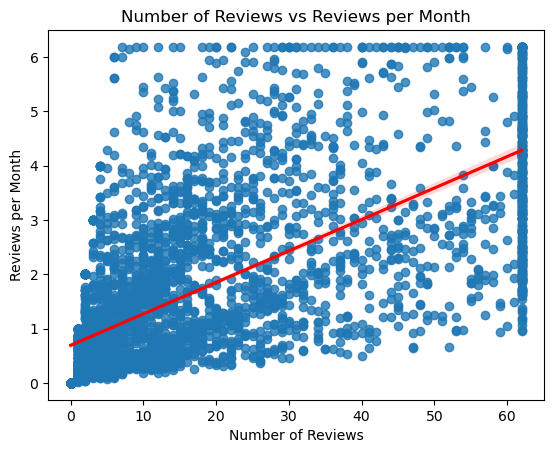

In [23]:
plt.figure(figsize=(16, 5))

# # Average Review Score by Room Type
plt.subplot(1, 2, 1)
df.groupby('Room Type')['Review Scores Rating'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Average Review Score by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Rating")

# Top 10 Property Types by Review Scores Rating
plt.subplot(1, 2, 2)
df.groupby('Property Type')['Review Scores Rating'].mean().sort_values().head(10).plot(kind='barh')
plt.title("Top 10 Property Types by Rating")
plt.xlabel("Rating")
plt.ylabel("Property Type")
plt.tight_layout()
plt.show()

# Correlation between Number of Reviews and Reviews per Month
corr_reviewsmonth_number = df['Reviews per Month'].corr(df['Number of Reviews'])
print(f"The correlation coefficient of Reviews per Month and Number of Reviews: {corr_reviewsmonth_number:.2f}")

sns.regplot(x='Number of Reviews', y='Reviews per Month', data=df, line_kws={'color': 'red'})
plt.title('Number of Reviews vs Reviews per Month')
plt.show()

**Interpretation:**

1. Review scores are consistently high across all room types with very little variation, indicating that customer satisfaction is stable and not significantly affected by accommodation type.

2. Different property types achieve similarly high ratings, suggesting that customer satisfaction remains strong across a variety of property categories with only minor differences.

3. There is a strong positive relationship between total reviews and reviews per month (correlation = 0.69), indicating that listings with more reviews tend to maintain higher ongoing demand and engagement.

## 3. Property Attributes & Amenities Insights

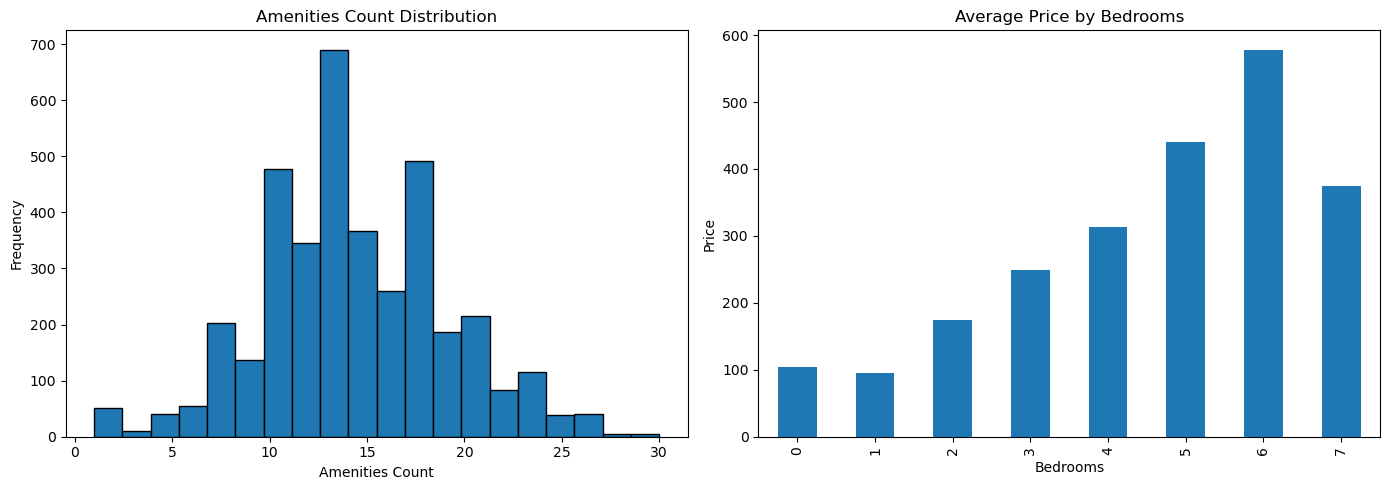

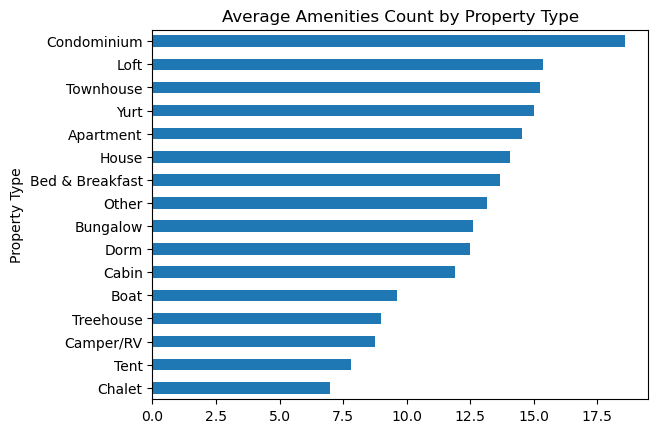

In [24]:
plt.figure(figsize=(14, 5))

# Amenities Count Distribution
plt.subplot(1, 2, 1)
df['Amenities Count'].plot(kind='hist', bins=20, edgecolor='black')
plt.title("Amenities Count Distribution")
plt.xlabel("Amenities Count")

# Average Price by Bedrooms
plt.subplot(1, 2, 2)
df.groupby('Bedrooms')['Price'].mean().plot(kind='bar')
plt.title("Average Price by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

# Average Amenities Count by Property Type
df.groupby('Property Type')['Amenities Count'].mean().sort_values().plot(
    kind='barh', title='Average Amenities Count by Property Type')
plt.show()

**Interpretation:**

1. Review scores are consistently high across all room types with very little variation, indicating that customer satisfaction is stable and not significantly affected by accommodation type.

2. Different property types achieve similarly high ratings, suggesting that customer satisfaction remains strong across a variety of property categories with only minor differences.

3. There is a strong positive relationship between total reviews and reviews per month (correlation ≈ 0.69), indicating that listings with more reviews tend to maintain higher ongoing demand and engagement.

## 4. Demand & Booking Behavior Trends

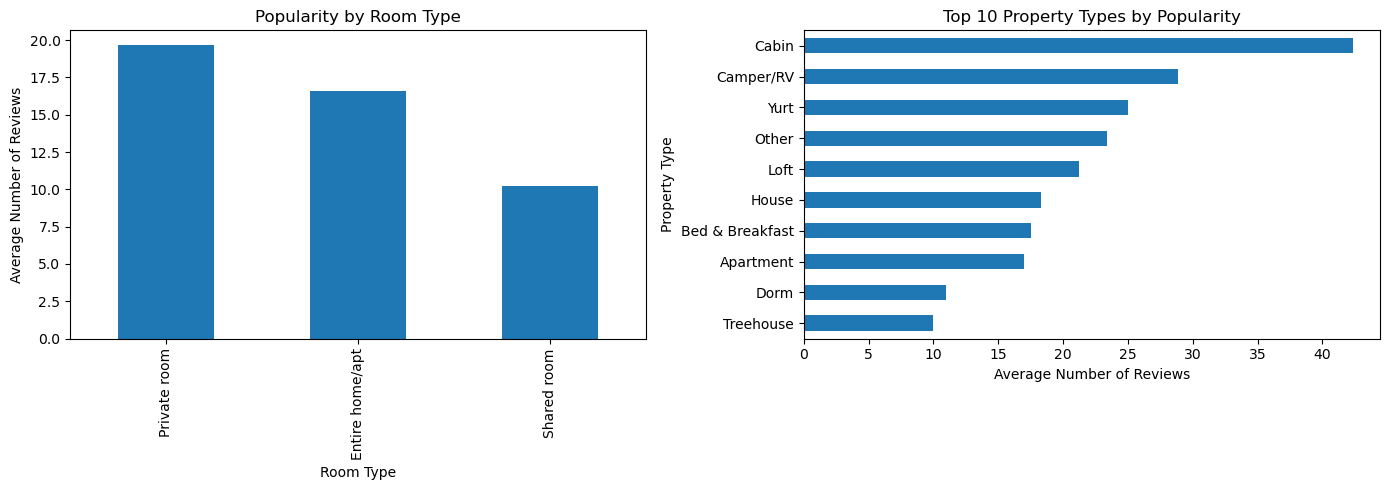

In [25]:
plt.figure(figsize=(14, 5))

# Popularity by Room Type
plt.subplot(1, 2, 1)
df.groupby('Room Type')['Number of Reviews'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Popularity by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Number of Reviews")

# Top 10 Property Type by Popularity
plt.subplot(1, 2, 2)
top10_property_demand = df.groupby('Property Type')['Number of Reviews'].mean().sort_values(ascending=False).head(10)

top10_property_demand.sort_values().plot(kind='barh')
plt.title("Top 10 Property Types by Popularity")
plt.xlabel("Average Number of Reviews")
plt.ylabel("Property Type")
plt.tight_layout()
plt.show()

**Interpretation:**

1. Private rooms receive the highest number of reviews, followed by entire homes, while shared rooms are less popular, indicating stronger demand for more private accommodation options.

2. Demand is highest for unique property types like cabins and camper/RVs, while traditional options like apartments and dorms show comparatively lower engagement, highlighting a preference for distinctive stays.

## 5. Cancellation & Security Policies

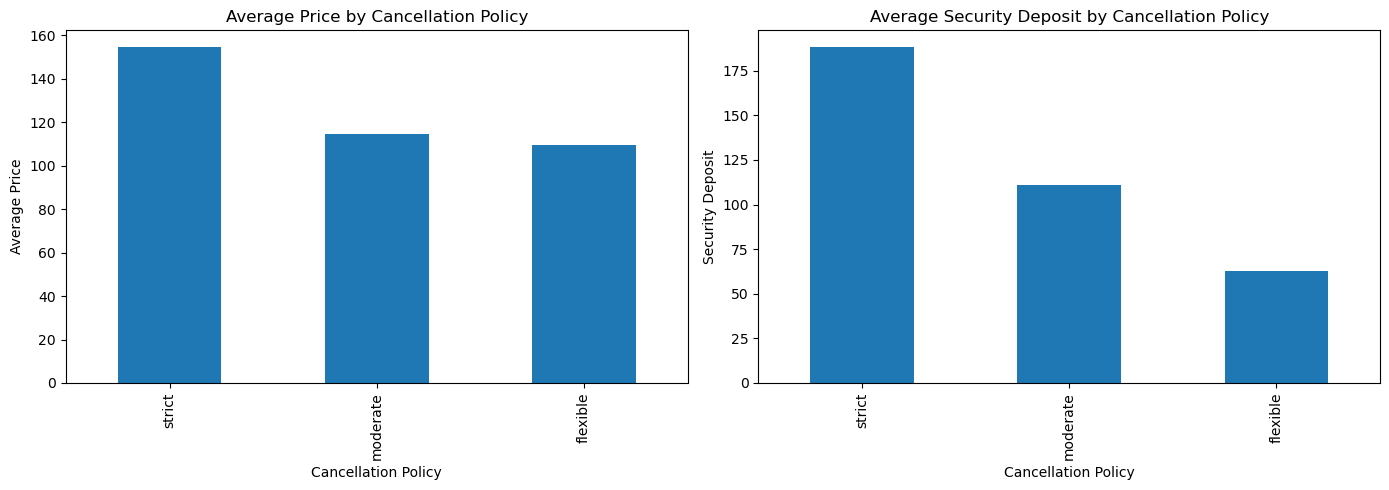

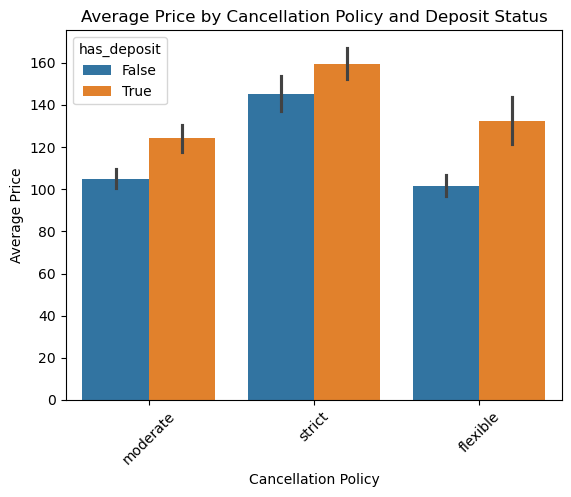

In [26]:
plt.figure(figsize=(14, 5))

# Average Price by Cancellation Policy
plt.subplot(1, 2, 1)
df.groupby('Cancellation Policy')['Price'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Average Price by Cancellation Policy")
plt.xlabel("Cancellation Policy")
plt.ylabel("Average Price")

# Average Security Deposit by Cancellation Policy
plt.subplot(1, 2, 2)
df.groupby('Cancellation Policy')['Security Deposit'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Average Security Deposit by Cancellation Policy")
plt.xlabel("Cancellation Policy")
plt.ylabel("Security Deposit")

plt.tight_layout()
plt.show()

# Average Price by Cancellation Policy and Deposit Status
df['has_deposit'] = df['Security Deposit'] > 0

sns.barplot(x='Cancellation Policy', y='Price', hue='has_deposit', data=df)
plt.title("Average Price by Cancellation Policy and Deposit Status")
plt.xlabel("Cancellation Policy")
plt.ylabel("Average Price")
plt.xticks(rotation = 45)
plt.show()

**Interpretation:**

1. Listings with stricter cancellation policies have higher average prices, while moderate and flexible policies are priced lower, indicating a trade-off between pricing power and customer flexibility.

2. Security deposits increase with stricter policies, showing that higher-priced listings tend to enforce stronger financial protection measures.

3. Listings with security deposits are consistently priced higher across moderate, strict, and flexible policies. The pattern is more stable than France, showing deposits are linked to higher pricing across all policy types.

# **Statistical Analysis**

In [27]:
# Import libraries

from scipy import stats
from scipy.stats import norm, ttest_ind

alpha = 0.05

## 1. Listing & Host Performance

**Test Used:** Two-Sample z-test

**Business Objective:**
To analyze how a host’s portfolio size (number of listings) influences their responsiveness to guests.

**Business Question:**
Do hosts with a larger number of listings exhibit different response rates compared to those with fewer listings?

**Hypotheses:**

Null Hypothesis (H₀): The mean host response rate is the same for hosts with high and low listing counts.

Alternative Hypothesis (H₁): The mean host response rate differs between hosts with high and low listing counts.

In [28]:
high = df[df['Host Listings Count'] > df['Host Listings Count'].median()]['Host Response Rate']
low = df[df['Host Listings Count'] <= df['Host Listings Count'].median()]['Host Response Rate']

# Z test
np.random.seed(42)

# Take samples of size 100
high_sample = np.random.choice(high, size=100, replace=False)
low_sample = np.random.choice(low, size=100, replace=False)

mean_high = np.mean(high_sample)
mean_low = np.mean(low_sample)

std_high = np.std(high_sample, ddof=1)
std_low = np.std(low_sample, ddof=1)

n1 = len(high_sample)
n2 = len(low_sample)

z_stat = (mean_high - mean_low) / np.sqrt((std_high**2 / n1) + (std_low**2 / n2))

p_val = 2 * (1 - norm.cdf(abs(z_stat)))
z_critical = stats.norm.ppf(1 - alpha/2)

print("\nZ-test (Sample size = 100)")
print("Sample size (high):", n1)
print("Sample size (low):", n2)
print("Z-statistic:", round(z_stat, 3))
print("z-critical value:", round(z_critical,3))
print("P-value:", round(p_val, 3))

print("H0: Response rate is same for different portfolio sizes")
print("H1: Response rate differs")

print("\np-value Method:")
if p_val < alpha:
    print("Rejected H0: Host portfolio size has a statistically significant effect on response rate.")
else:
    print("Failed to reject H0: No statistically significant difference in response rates.")

print("\nCritical Value Method:")
if abs(z_stat) > z_critical:
    print("Rejected H0: Host portfolio size has a statistically significant effect on response rate.")
else:
    print("Failed to reject H0: No statistically significant difference in response rates.")


Z-test (Sample size = 100)
Sample size (high): 100
Sample size (low): 100
Z-statistic: 1.448
z-critical value: 1.96
P-value: 0.148
H0: Response rate is same for different portfolio sizes
H1: Response rate differs

p-value Method:
Failed to reject H0: No statistically significant difference in response rates.

Critical Value Method:
Failed to reject H0: No statistically significant difference in response rates.


**Statistical Interpretation:**
- Random samples of 100 hosts were selected from both the high-listing and low-listing groups for comparison.
- The two-sample z-test based on sampled data shows no statistically significant difference in host response rates between high-listing and low-listing hosts (Z = 1.448, p = 0.148).
- For the p-value method, since the p-value > 0.05, we fail to reject the null hypothesis.
- For the critical value method, since the calculated z-statistic (1.448) lies within the acceptance region (-1.96 to +1.96), we fail to reject the null hypothesis.
- Both the p-value method and the critical value method lead to the same conclusion: the null hypothesis cannot be rejected. Therefore, portfolio size does not appear to have a statistically significant impact on host responsiveness.

## 2. Customer Experience & Satisfaction

**Test Used:** Two sample t-test

**Business Objective:** 
Analyze whether room type impacts customer satisfaction

**Business Question:**
Do entire homes receive higher ratings than private rooms?

**Hypotheses:**

Null Hypothesis (H₀): The mean review rating is the same for entire homes/apartments and private rooms.

Alternative Hypothesis (H₁): The mean review rating differs between entire homes/apartments and private rooms.

In [29]:
entire = df[df['Room Type'] == 'Entire home/apt']['Review Scores Rating']
private = df[df['Room Type'] == 'Private room']['Review Scores Rating']

# t-test
np.random.seed(42)

# Take samples of size 30
entire_sample = np.random.choice(entire, size=30, replace=False)
private_sample = np.random.choice(private, size=30, replace=False)

t_stat, p_val = ttest_ind(entire_sample, private_sample, equal_var=False)

print("\nT-test (Sample size = 30)")
print("Sample size (entire):", len(entire_sample))
print("Sample size (private):", len(private_sample))
print("T-statistic:", round(t_stat, 3))
print("P-value:", round(p_val, 3))

print("H0: Mean rating is same for both room types")
print("H1: Mean rating differs based on room type")

if p_val < alpha:
    print("\nRejected H0")
    print("Room type has a statistically significant effect on guest satisfaction (ratings).")
else:
    print("\nFailed to reject H0")
    print("No statistically significant difference in ratings between room types.")


T-test (Sample size = 30)
Sample size (entire): 30
Sample size (private): 30
T-statistic: 1.685
P-value: 0.097
H0: Mean rating is same for both room types
H1: Mean rating differs based on room type

Failed to reject H0
No statistically significant difference in ratings between room types.


**Statistical Interpretation:**

- Random samples of 30 listings were selected from both the entire home and private room groups for comparison.
- The two-sample t-test based on sampled data shows no statistically significant difference in mean review ratings between entire homes and private rooms (t = 1.685, p = 0.097).
- Since the p-value > 0.05, we fail to reject the null hypothesis, indicating that room type does not significantly influence customer satisfaction.

## 3. Demand & Booking Behavior Trends

**Test Used:** Two-sample two-tailed t-test

**Business Objective:**
To determine whether listings with higher demand receive significantly different customer ratings compared to lower-demand listings.

**Business Question:**

Do high-demand listings have different (better or worse) ratings than low-demand listings?

**Hypotheses:**

Null Hypothesis (H₀): There is no difference in average ratings between the two groups.

Alternative Hypothesis (H₁): There is a significant difference in ratings between the two groups.

In [30]:
median_demand = df['Reviews per Month'].median()

low = df[df['Reviews per Month'] <= median_demand]['Review Scores Rating']
high = df[df['Reviews per Month'] > median_demand]['Review Scores Rating']

# t-test
np.random.seed(42)

# Take samples of size 30
low_sample = np.random.choice(low, size=30, replace=False)
high_sample = np.random.choice(high, size=30, replace=False)

# Perform t-test on samples
t_stat, p_val = ttest_ind(low_sample, high_sample, equal_var=False)

print("\nT-test (Sample size = 30)")
print("Sample size (low demand):", len(low_sample))
print("Sample size (high demand):", len(high_sample))
print("T-statistic:", round(t_stat, 3))
print("P-value:", round(p_val, 3))

print("H₀: There is no difference in customer ratings between low-demand and high-demand listings.")
print("H₁: There is a significant difference in customer ratings between low-demand and high-demand listings.")

if p_val < alpha:
    print("\nRejected H₀")
    print("Customer ratings differ significantly between high-demand and low-demand listings.")
else:
    print("\nFailed to reject H₀")
    print("No statistically significant difference in customer ratings between the two groups.")


T-test (Sample size = 30)
Sample size (low demand): 30
Sample size (high demand): 30
T-statistic: -0.262
P-value: 0.795
H₀: There is no difference in customer ratings between low-demand and high-demand listings.
H₁: There is a significant difference in customer ratings between low-demand and high-demand listings.

Failed to reject H₀
No statistically significant difference in customer ratings between the two groups.


**Statistical Interpretation:**

- Random samples of 30 listings were selected from both the low-demand and high-demand groups for comparison.
- The two-sample t-test shows no statistically significant difference in ratings between high-demand and low-demand listings (t = -0.262, p = 0.795).
- Since the p-value > 0.05, we fail to reject the null hypothesis, indicating that demand level does not significantly influence customer ratings.

## 4. Cancellation & Security Policies

**Test Used:** Two-Sample z-test

**Business Objective:**
Evaluate whether flexible policies improve satisfaction

**Business Question:**
Do flexible policies lead to higher ratings?

**Hypotheses:**

Null Hypothesis (H₀): The mean review rating is the same for flexible and strict cancellation policies.

Alternative Hypothesis (H₁): The mean review rating differs between flexible and strict cancellation policies.

In [31]:
flex = df[df['Cancellation Policy'] == 'flexible']['Review Scores Rating']
strict = df[df['Cancellation Policy'] == 'strict']['Review Scores Rating']

# Z-test
np.random.seed(42)

# Take samples of size 100
flex_sample = np.random.choice(flex, size=100, replace=False)
strict_sample = np.random.choice(strict, size=100, replace=False)

mean1 = np.mean(flex_sample)
mean2 = np.mean(strict_sample)

std1 = np.std(flex_sample, ddof=1)
std2 = np.std(strict_sample, ddof=1)

n1 = len(flex_sample)
n2 = len(strict_sample)

z_stat = (mean1 - mean2) / np.sqrt((std1**2 / n1) + (std2**2 / n2))

p_val = 2 * (1 - norm.cdf(abs(z_stat)))

z_critical = stats.norm.ppf(1 - alpha/2)

print("\nZ-test (Sample size = 100)")
print("Sample size (flexible):", n1)
print("Sample size (strict):", n2)
print("Z-statistic:", round(z_stat, 3))
print("z-critical value:", round(z_critical, 3))
print("P-value:", round(p_val, 3))

print("H0: Mean rating is same for cancellation policies")
print("H1: Mean rating differs based on policy")

print("\np-value Method:")
if p_val < alpha:
    print("Rejected H0: Cancellation policy has a statistically significant effect on guest satisfaction (ratings).")
else:
    print("Failed to reject H0: No statistically significant difference in ratings between cancellation policies.")

# Step 10: Critical value method
print("\nCritical Value Method:")
if abs(z_stat) > z_critical:
    print("Rejected H0: Cancellation policy has a statistically significant effect on guest satisfaction (ratings).")
else:
    print("Failed to reject H0: No statistically significant difference in ratings between cancellation policies.")


Z-test (Sample size = 100)
Sample size (flexible): 100
Sample size (strict): 100
Z-statistic: 1.235
z-critical value: 1.96
P-value: 0.217
H0: Mean rating is same for cancellation policies
H1: Mean rating differs based on policy

p-value Method:
Failed to reject H0: No statistically significant difference in ratings between cancellation policies.

Critical Value Method:
Failed to reject H0: No statistically significant difference in ratings between cancellation policies.


**Statistical Interpretation:**

- Random samples of 100 listings were selected from both the flexible and strict cancellation policy groups for comparison.
- The two-sample z-test shows no statistically significant difference in ratings between flexible and strict cancellation policies (Z = 1.235, p = 0.217).
- For the p-value method, since the p-value > 0.05, we fail to reject the null hypothesis.
- For the critical value method, since the calculated z-statistic (1.235) lies within the acceptance region (-1.96 to +1.96), we fail to reject the null hypothesis.
- Both the p-value method and the critical value method lead to the same conclusion: the null hypothesis cannot be rejected. Therefore, cancellation policy type does not appear to have a statistically significant influence on customer satisfaction.

## Machine Learning

In [32]:
df_ml = df.copy()

In [33]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [34]:
# Drop some columns

drop_cols = ['Host ID','ID', 'Host Name', 'Host Since','Country','Host Year']
df_ml = df_ml.drop(columns=drop_cols)

num_cols =  ['Host Response Rate', 'Host Listings Count', 'Accommodates','Bathrooms', 'Bedrooms', 'Beds',
             'Price', 'Security Deposit', 'Cleaning Fee', 'Guests Included', 'Extra People', 'Minimum Nights', 
             'Maximum Nights', 'Number of Reviews', 'Review Scores Rating', 'Reviews per Month', 'Amenities Count']
             
categorical_cols = df_ml.select_dtypes(include=["object"]).columns

# Encoding

le = LabelEncoder()

for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

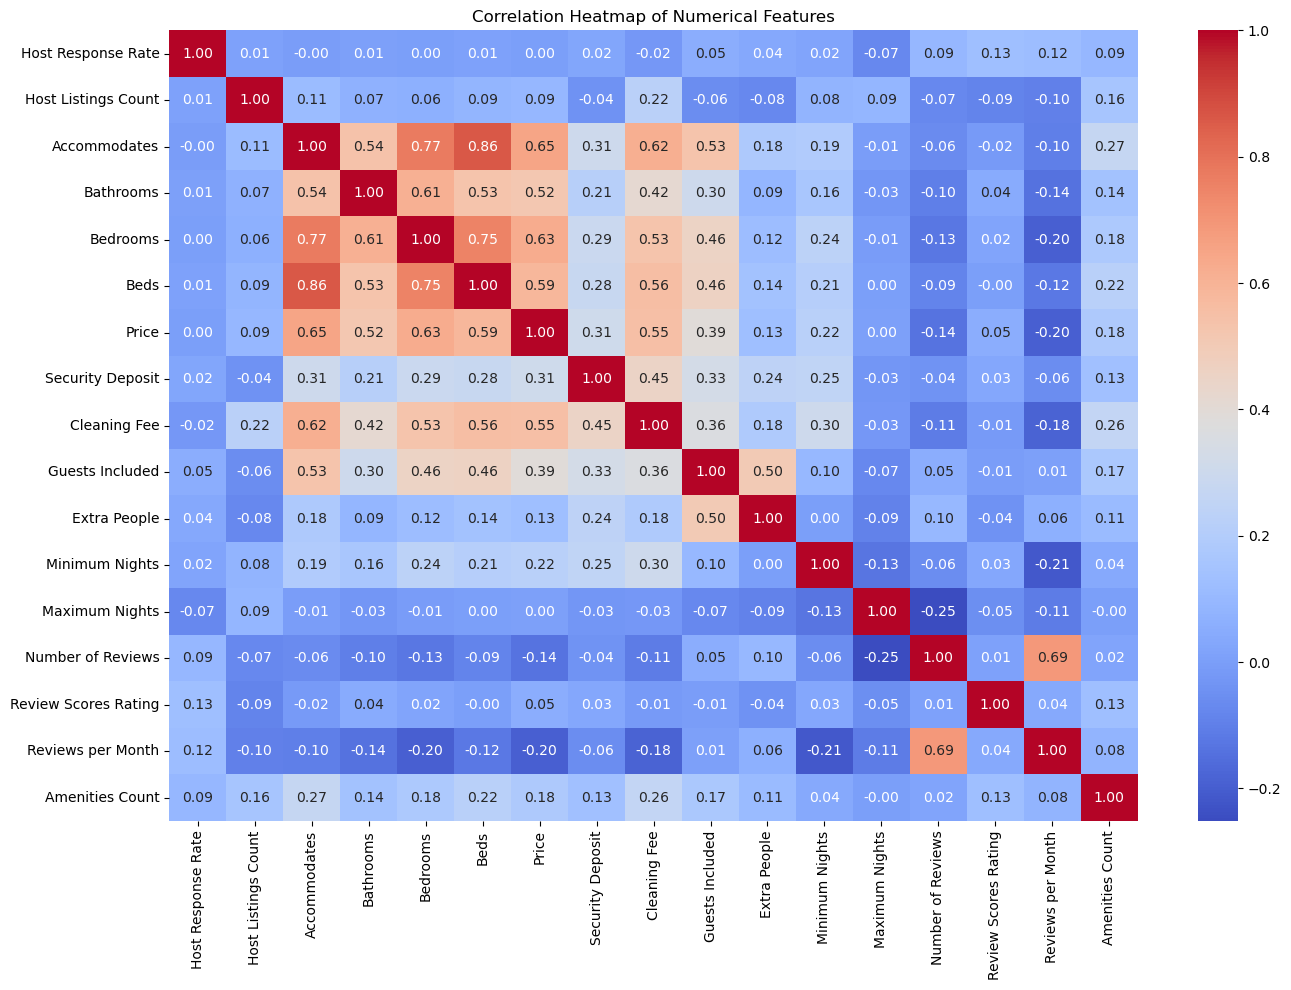

In [35]:
# Correlation Heatmap of Numerical Features
corr = df_ml[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [36]:
# Drop columns with high correlation with each other

df_ml = df_ml.drop(columns=['Beds', 'Number of Reviews'])

## 1. Price Prediction Model

**Model Used:** Simple Linear Regression

**Business Objective:** 
To analyze how listing characteristics influence pricing and evaluate the ability to predict price.

**Business Question:**
Can listing features effectively predict Airbnb prices?

In [37]:
# One feature and target
X = df_ml[['Accommodates']]
y = df_ml['Price']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Model fitting
lr_simple = LinearRegression()
lr_simple.fit(X_train, y_train)

# Model prediction
y_pred = lr_simple.predict(X_test)

# Print model evaluation
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R2: {r2_score(y_test, y_pred):.3f}")

MAE: 43.84
RMSE: 67.67
MSE: 4579.75
R2: 0.451


**Model Interpretation:**

- The model shows moderate performance, explaining about 45% of price variation using accommodates. This indicates that listing capacity (number of guests) is a key factor influencing price in Seattle.
- The error values (MAE ≈ 43.84, RMSE ≈ 67.67) indicate some prediction deviations. The relatively higher R² compared to France suggests a stronger and more consistent relationship between size and pricing. However, prediction errors indicate that other features like amenities and location still play a role.
- Pricing in Seattle is more capacity-driven, where larger listings tend to have predictably higher prices.

## 2. Price Prediction (Multiple Features)

**Model Used:** Multiple Linear Regression

**Business Objective:**
To analyze how multiple property attributes and amenities collectively influence listing prices.

**Business Question:**
Can a combination of property features and amenities improve the accuracy of price prediction?

In [38]:
df_ml.corr()['Price'].sort_values(ascending=False)

Price                   1.000000
Accommodates            0.652647
Bedrooms                0.627972
Cleaning Fee            0.554742
Bathrooms               0.516284
Guests Included         0.393140
Security Deposit        0.307695
Minimum Nights          0.222824
Cancellation Policy     0.209918
Amenities Count         0.183647
has_deposit             0.164348
Extra People            0.126086
Bed Type                0.115240
Host Listings Count     0.093962
Amenities               0.073923
Review Scores Rating    0.052851
Property Type           0.045176
Maximum Nights          0.004137
Host Response Rate      0.002039
State                  -0.004118
Zipcode                -0.017694
Reviews per Month      -0.196114
Room Type              -0.430066
City                         NaN
Name: Price, dtype: float64

In [39]:
mlr_features = [
    'Accommodates', 'Bedrooms', 'Bathrooms', 'Cleaning Fee','Security Deposit', 'Extra People', 'Guests Included', 'Amenities Count']

X = df_ml[mlr_features]
y = df_ml['Price']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=26)

# Model fitting
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)

# Model prediction
y_pred = lr_multi.predict(X_test)

# Print model evaluation
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"R2: {r2_score(y_test, y_pred):.3f}")

MAE: 43.36
RMSE: 63.21
MSE: 3995.67
R2: 0.524


**Model Interpretation:**

- The model shows stronger predictive performance, explaining about 52.4% of the variation in listing prices.
- The error values (MAE and RMSE) indicate improved accuracy, confirming that using multiple features provides a better representation of pricing patterns.
- This suggests that pricing in Seattle is more structured and strongly influenced by listing characteristics such as capacity, amenities, and property features.
- Compared to France, the higher R² indicates that price is more predictable and consistently driven by observable factors.
- Pricing in Seattle is feature-driven and more systematic, allowing better prediction and clearer pricing strategies for hosts.

## 3. Security Deposit Classification

**Model Used:** Logistic Regression

**Business Objective:**
To determine whether an Airbnb listing requires a security deposit based on pricing, property characteristics, host attributes, and booking-related features.

**Business Question:**
Can pricing, property, host, and booking characteristics predict whether an Airbnb listing requires a security deposit?

Logistic Regression Evaluation
Accuracy: 0.7

Confusion Matrix:
 [[282 106]
 [124 252]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.69      0.73      0.71       388
         1.0       0.70      0.67      0.69       376

    accuracy                           0.70       764
   macro avg       0.70      0.70      0.70       764
weighted avg       0.70      0.70      0.70       764

ROC-AUC Score: 0.78


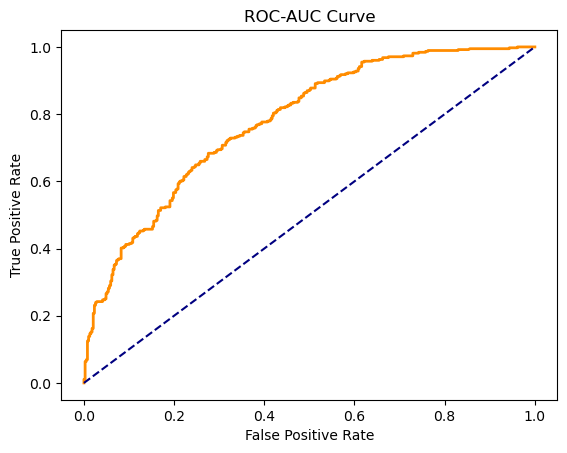

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score
from sklearn.metrics import roc_curve, auc

# Create Target Variable
df_ml['has_deposit'] = df['Security Deposit'] > 0

# Seperate features and target
X = df_ml[[
    'Price',
    'Cleaning Fee',
    'Extra People',
    'Accommodates',
    'Bedrooms',
    'Host Listings Count',
    'Reviews per Month',
    'Cancellation Policy'
]]
y = df_ml['has_deposit']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Model fitting
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Model prediction
y_pred_log = log_reg.predict(X_test)
y_prob_log = log_reg.predict_proba(X_test)[:, 1]

# Print model evaluation
print("Logistic Regression Evaluation")
print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob_log), 2))

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_log):.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.show()

**Model Interpretation:**

- The logistic regression model was developed to predict whether an Airbnb listing requires a security deposit using pricing variables, property characteristics, and host-related features.
- The model achieved an accuracy of 70% and a ROC-AUC score of 0.78, indicating a good ability to distinguish between listings with and without security deposits.
- The confusion matrix shows relatively balanced classification performance across both classes, with the model correctly identifying listings without security deposits slightly more effectively (recall = 0.73) than listings requiring security deposits (recall = 0.67).
- Precision and recall values ranging between 0.69 and 0.70 suggest that the model performs consistently across categories without significant classification bias.
- Overall, the findings indicate that security deposit requirements are influenced by measurable listing, pricing, and host characteristics, demonstrating that host deposit decisions can be reasonably predicted using Airbnb listing data.

## 4. Demand Segmentation

**Model Used:** KNN (K-Nearest Neighbors)

**Business Objective:** Classify listings based on demand intensity.

**Business Question:** Can we classify listings into high-demand and low-demand segments?

In [41]:
df_ml['high_demand'] = (df_ml['Reviews per Month'] > df_ml['Reviews per Month'].median())

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

X = df_ml[[
    'Price',
    'Cleaning Fee',
    'Accommodates',
    'Bedrooms',
    'Bathrooms',
    'Guests Included',
    'Amenities Count',
    'Review Scores Rating'
]]
y = df_ml['high_demand']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = range(1,7)
accuracy_scores = []
roc_auc_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)
    y_prob = knn.predict_proba(X_test_scaled)[:, 1]

    accuracy_scores.append(accuracy_score(y_test, y_pred))
    roc_auc_scores.append(roc_auc_score(y_test, y_prob))

    print(f"K={k:2d} | Accuracy={accuracy_scores[-1]:.3f} | ROC-AUC={roc_auc_scores[-1]:.3f}")

K= 1 | Accuracy=0.615 | ROC-AUC=0.615
K= 2 | Accuracy=0.598 | ROC-AUC=0.638
K= 3 | Accuracy=0.620 | ROC-AUC=0.658
K= 4 | Accuracy=0.622 | ROC-AUC=0.672
K= 5 | Accuracy=0.648 | ROC-AUC=0.684
K= 6 | Accuracy=0.626 | ROC-AUC=0.677


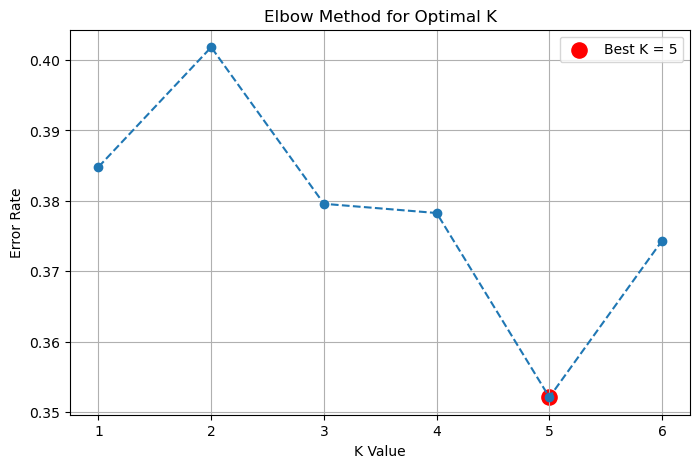

In [42]:
error_rate = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    error_rate.append(np.mean(y_pred != y_test))

# Plot Error Rate vs K
plt.figure(figsize=(8,5))

plt.plot(k_values, error_rate, marker='o', linestyle='--')

best_k = k_values[error_rate.index(min(error_rate))]
best_error = min(error_rate)

plt.scatter(best_k, best_error, color='red', s=120,
            label=f'Best K = {best_k}')

plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_values)
plt.grid(True)
plt.legend()

plt.show()

KNN Classification Evaluation
Accuracy: 0.64

Confusion Matrix:
 [[240 131]
 [144 249]]

Classification Report:
               precision    recall  f1-score   support

       False       0.62      0.65      0.64       371
        True       0.66      0.63      0.64       393

    accuracy                           0.64       764
   macro avg       0.64      0.64      0.64       764
weighted avg       0.64      0.64      0.64       764

ROC-AUC Score: 0.66


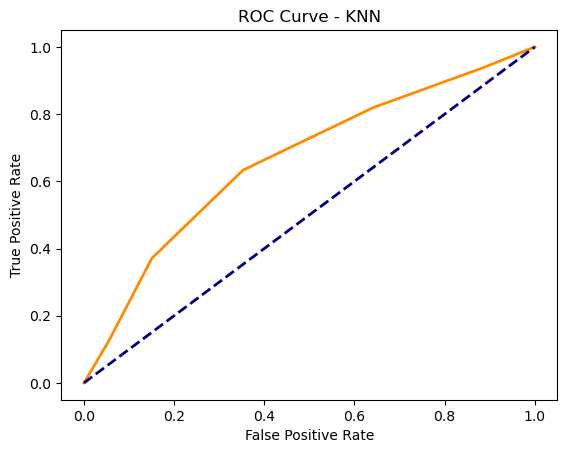

In [43]:
# Model fitting
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Model prediction
y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]

# Print model evaluation
print("KNN Classification Evaluation")
print("Accuracy:", round(accuracy_score(y_test, y_pred_knn), 2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob_knn), 2))

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.show()

**Performance Summary:**
- **Accuracy:** 0.64
- **ROC-AUC:** 0.66

**Model Interpretation:**
- The model shows moderate performance, with 64% accuracy and a ROC-AUC of 0.66, indicating a reasonable but weaker ability to distinguish between high- and low-demand listings compared to France.
- The ROC curve lies above the diagonal, confirming the model performs better than random, but not strongly.
- Precision and recall are fairly balanced (~0.62–0.66), meaning the model is consistent but not highly precise in identifying demand levels.
- The confusion matrix indicates noticeable overlap between classes, leading to some misclassification.
- While listing features still influence demand, the relationship in Seattle appears less strong or more uniform, making demand slightly harder to predict using these variables alone.

## 5. Demand Segmentation

**Model Used:** K-Means Clustering

**Business Objective:**
To segment listings based on price and accommodation capacity to identify distinct market groups.

**Business Question:**
Can listings be grouped into meaningful segments using price and accommodates to understand different market tiers?

In [44]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = df_ml[['Price', 'Accommodates']]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_values = range(2, 11)

inertia_scores = []
silhouette_scores = []

print("K | Inertia | Silhouette Score")
print("-" * 40)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    inertia = kmeans.inertia_
    sil_score = silhouette_score(X_scaled, labels)

    inertia_scores.append(inertia)
    silhouette_scores.append(sil_score)

    print(f"{k} | {inertia:.2f} | {sil_score:.4f}")

K | Inertia | Silhouette Score
----------------------------------------
2 | 3669.46 | 0.6012
3 | 2429.98 | 0.5029
4 | 1899.38 | 0.4846
5 | 1624.90 | 0.4824
6 | 1352.54 | 0.4677
7 | 1147.65 | 0.4509
8 | 1011.96 | 0.4528
9 | 905.74 | 0.4523
10 | 775.50 | 0.4580


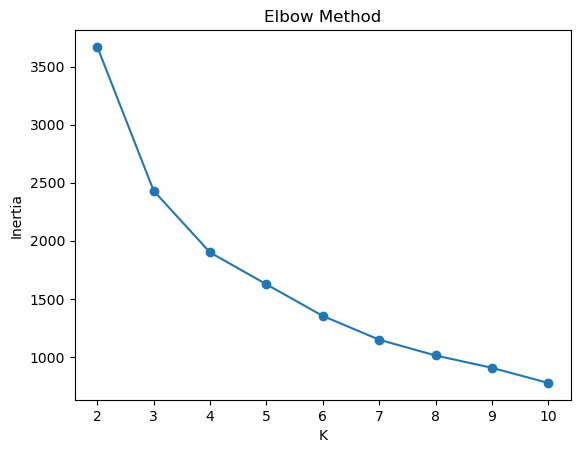

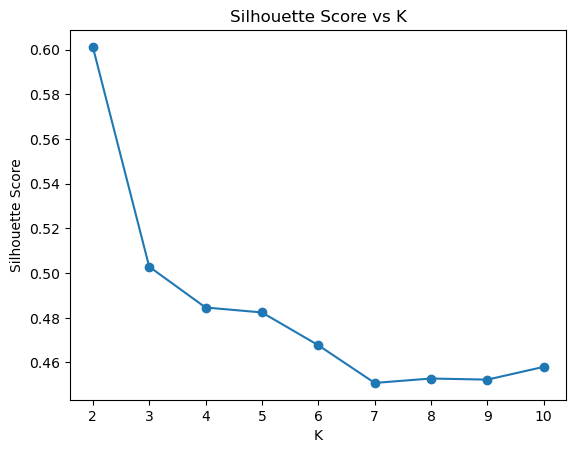

In [45]:
# Elbow Plot
plt.figure()
plt.plot(k_values, inertia_scores, marker='o')
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Silhouette Plot
plt.figure()
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.show()

Listing_Cluster
0    2187
1     310
2    1319
Name: count, dtype: int64

Cluster Centroids:
        Price  Accommodates
0   86.188386      2.034294
1  348.080645      7.532258
2  145.462472      4.548901


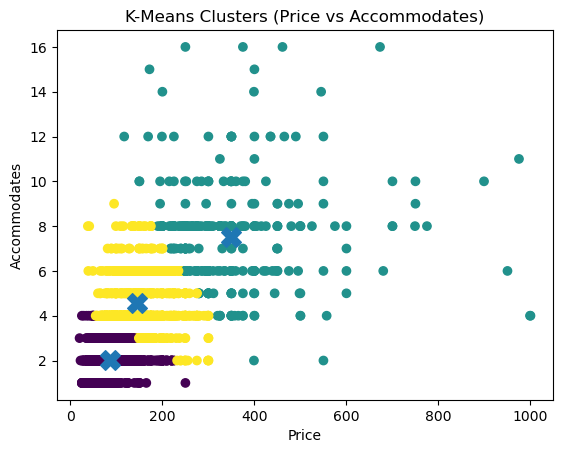

In [46]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_ml['Listing_Cluster'] = kmeans.fit_predict(X_scaled)

cluster_counts = df_ml['Listing_Cluster'].value_counts().sort_index()

print(cluster_counts)

centroids_scaled = kmeans.cluster_centers_

# Convert back to original scale
centroids = scaler.inverse_transform(centroids_scaled)

centroid_df = pd.DataFrame(centroids, columns=['Price', 'Accommodates'])

print("\nCluster Centroids:")
print(centroid_df)

plt.figure()

plt.scatter(
    df_ml['Price'],
    df_ml['Accommodates'],
    c=df_ml['Listing_Cluster']
)

# Plot centroids
plt.scatter(
    centroid_df['Price'],
    centroid_df['Accommodates'],
    marker='X',
    s=200
)

plt.xlabel("Price")
plt.ylabel("Accommodates")
plt.title("K-Means Clusters (Price vs Accommodates)")
plt.show()

In [47]:
# K-means clustering evaluation metrics

from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

# Cluster labels
cluster_labels = kmeans.labels_

# Silhouette Score
silhouette_avg = silhouette_score(X_scaled, cluster_labels)
print("Silhouette Score:", round(silhouette_avg, 3))

# Calinski-Harabasz Score
calinski_harabasz = calinski_harabasz_score(X_scaled, cluster_labels)
print("Calinski-Harabasz Score:", round(calinski_harabasz, 3))

# Davies-Bouldin Index
davies_bouldin = davies_bouldin_score(X_scaled, cluster_labels)
print("Davies-Bouldin Index:", round(davies_bouldin, 3))

Silhouette Score: 0.503
Calinski-Harabasz Score: 4081.367
Davies-Bouldin Index: 0.804


**Model Interpretation:**
- The K-Means model successfully segments listings into three clear market tiers based on price and accommodation capacity, showing a structured relationship between listing size and pricing.
- The evaluation metrics (Silhouette ≈ 0.50, good Calinski-Harabasz, and low Davies-Bouldin index) indicate reasonably well-defined and reliable clusters.
- The results highlight that the market is naturally divided into budget, mid-range, and premium segments, where pricing consistently increases with accommodation capacity.
- This confirms that listing size is a key driver of pricing and demand segmentation in Seattle, and the clustering effectively captures these underlying patterns.

The K-Means model identifies 3 clusters (K = 3) with a good silhouette score (~0.50), indicating reasonably well-separated segments. Using price and accommodates, the model captures clear market tiers.

**Cluster 0 (Budget Segment)**
- Low price (86) and low accommodates (2)
- Small, affordable listings
- Largest segment, reflecting strong demand for budget stays

**Cluster 2 (Mid-Range Segment)**
- Moderate price (145) and accommodates (4–5)
- Balanced offerings between cost and capacity
- Core market segment

**Cluster 1 (Premium Segment)**
- High price (348) and higher accommodates (7–8)
- Large, premium listings targeting bigger groups
- Smallest but high-value segment